# 07 — Cross-year data sanity checks

Side-by-side summary statistics for every senatorial election year we have
(`2013`, `2016`, `2019`, `2022`, `2025`), read straight from `data/elections/`
via each year's config. Use it to catch anything that looks off before trusting
the unmixing outputs: precinct/candidate counts, the regional spread of
precincts, top vote-getters, registration/turnout totals, and basic data-hygiene
flags.

The five files do **not** share one schema — 2013 and 2016 are a reduced layout
(`sen_col_start = 6`, registered voters only), the others use the fuller COMELEC
layout (`sen_col_start = 17`) and even differ among themselves (abstentions
column, candidate counts, region labels). So everything here keys off each
year's config rather than assuming a fixed column layout.

**2016 is a partial source.** It is built (`scripts/prepare_2016_csv.py`) from an
election-night transmission feed (`results_nle2016_05092016_1950.txt`) that
covers only ~22,986 senator precincts — roughly **25%** of the ~92,509 national.
Its geography is **recovered separately** (`scripts/scrape_2016_pop.py`) from
COMELEC's 2016 Project of Precincts, keyed to the feed's precinct ids
(`province+municipality+cluster`), with the 2019 file filling ids POP can't key
(NCR/big cities): **97.9%** of the feed's precincts get region/province/
municipality/barangay, so 2016 has real maps; the remaining ~2% carry a
`PLACEHOLDER` geography. Still treat 2016 as a partial-data sanity check on
coverage, not a complete national result. See `data/README.md`.

## Summary

Snapshot of what this notebook found (rerun the cells to refresh — these numbers
are from the last run):

| | 2013 | 2016 | 2019 | 2022 | 2025 |
|---|---|---|---|---|---|
| raw precincts | 77,830 | 22,986 | 85,116 | 106,024 | 92,822 |
| kept precincts | 59,679 | 22,986 | 85,113 | 105,033 | 92,486 |
| candidates (raw / kept) | 33 / 31 | 50 / 50 | 61 / 32 | 64 / 34 | 66 / 42 |
| normalization | row_max | row_max | valid_ballots | valid_ballots | valid_ballots |
| turnout | — | — | 75.95% | 83.38% | 82.21% |

- **Top vote-getters match the real topnotchers** every year (Poe 2013, Villar
  2019, Padilla 2022, Go 2025) — the end-to-end read of each file is sound. 2016's
  leaders (Villanueva, Drilon, Sotto, Gordon, Lacson, Hontiveros…) are all genuine
  winners, but this is a ~25% election-night snapshot, so the *ranking* is
  provisional, not the final national order.
- Turnout for 2019/2022/2025 sits in a plausible 76–83% band.

### ⚠️ Things to check
1. **2025: valid ballots (62.6M) > actual voters (57.0M) → 110%** (§4). Valid
   ballots can't exceed the number of people who voted. Worse, `valid_ballots`
   *equals* `actual_voters` **exactly** in 2019 and 2022 (100.0%). So
   `information.numberOfValidBallot` is inconsistent across years and looks
   unreliable — and it's the **normalization denominator** for those three
   years, so verify what the 2025 column actually holds.
2. **2013: 18,151 "dropped" precincts are empty placeholder rows** (0 votes and
   0 registered), heavily concentrated in ARMM (65%), Region IX / CAR (~38%);
   the effective dataset is ~59.7k precincts (§7). Not a filtering problem.
3. **2013 has no valid-ballot or turnout columns** — only registered voters —
   so it uses `row_max` normalization and the site's weighted view equals the
   unweighted one (§1, §4).
4. **Region labels don't align across years** (2013 `ARMM`/`CARAGA` vs later
   `BARMM`/`REGION XIII`; 2025 adds `NEGROS ISLAND REGION`; `OV`/`LAV`/`OAV`
   overseas/absentee appear only some years) — cross-year region joins need
   explicit mapping, not a naive merge (§2).
5. **RESOLVED — overseas precincts.** The 2025 max of 18,630 votes in one
   precinct (§5) was an overseas (`OV`) precinct (`OV / ASIA PACIFIC`): all 28
   precincts with any candidate >1,000 votes are `OV`, while normal local
   precincts top out at 993. Checking exclusions surfaced a real gap — 2022 codes
   its overseas precincts `OAV`, which was *not* in `excluded_regions`, so 631
   overseas precincts were leaking into the 2022 unmixing. **Fixed:**
   `config_2022.ini` now excludes `OV, LAV, OAV` (2022 kept precincts
   105,664 → 105,033).
6. Candidate counts and the number dropped by the 25th-pctile filter vary a lot
   by year (§1, §5) — expected (minor candidates), but note how few 2019 keeps
   (32 of 61).
7. **2016 is a ~25% election-night snapshot** — `row_max` normalization, no
   turnout columns. Geography is recovered from COMELEC's 2016 Project of
   Precincts (`scripts/scrape_2016_pop.py`), so §2 now shows real regions, and
   2016's provinces/municipalities join the shapefiles about as well as 2019
   (~0.95 municipality match); ~2% of precincts COMELEC's page can't key stay as
   a `PLACEHOLDER` bucket. Its counts and archetypes are a partial-coverage
   sanity check; a complete national feed would supersede it. The older
   `results_nle2016_05122016_1545.csv` adds nothing — it is a strict subset of
   this feed once its stripped leading zeros are restored (0 precincts unique to
   it).

In [14]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

YEARS = ['2013', '2016', '2019', '2022', '2025']


def clean_name(header):
    """'1. ABALOS\n BENHUR (PFP)' / '5. AQUINO, BAM (KNP)' -> readable name."""
    name = header.split('.', 1)[1] if '.' in header else header
    return ' '.join(str(name).split())


# Load raw + preprocessed once per year.
D = {}
for yr in YEARS:
    cfg = load_config(f'../configs/config_{yr}.ini')
    scs = cfg['preprocessing'].getint('sen_col_start')
    df = load_complete(cfg)
    cand_cols = list(df.columns[scs:])
    pre = preprocess_from_config(df, cfg, verbose=False)
    D[yr] = dict(cfg=cfg, df=df, scs=scs, cand_cols=cand_cols, pre=pre)
    print(f'{yr}: loaded {len(df):,} precincts x {len(cand_cols)} candidate columns')

2013: loaded 77,830 precincts x 33 candidate columns
2016: loaded 22,986 precincts x 50 candidate columns
2019: loaded 85,116 precincts x 61 candidate columns
2022: loaded 106,024 precincts x 64 candidate columns
2025: loaded 92,822 precincts x 66 candidate columns


## 1. Overview summary

One column per year. `kept_*` are what survives preprocessing (candidate 25th-pctile
and precinct min-vote filters); `dropped_*` is the difference.

In [15]:
def overview(yr):
    d = D[yr]
    df, pre, cand = d['df'], d['pre'], d['cand_cols']
    cols = df.columns
    votes = df[cand].apply(pd.to_numeric, errors='coerce')
    row = {
        'raw_precincts': len(df),
        'raw_candidates': len(cand),
        'kept_precincts': pre.Y.shape[1],
        'kept_candidates': pre.Y.shape[0],
        'dropped_precincts': len(df) - pre.Y.shape[1],
        'dropped_candidates': len(cand) - pre.Y.shape[0],
        'normalization': d['cfg']['preprocessing'].get('normalization'),
        'n_archetypes (cfg)': d['cfg']['unmixing'].getint('n_archetypes'),
        'n_regions': df['REGION'].nunique(),
        'total_senator_votes': int(votes.to_numpy().sum()),
    }
    for label, col in [('registered_voters', 'information.numberOfRegisteredVoters'),
                       ('actual_voters', 'information.numberOfActuallyVoters'),
                       ('valid_ballots', 'information.numberOfValidBallot')]:
        row[f'total_{label}'] = int(pd.to_numeric(df[col], errors='coerce').sum()) if col in cols else np.nan
    reg, act = 'information.numberOfRegisteredVoters', 'information.numberOfActuallyVoters'
    if reg in cols and act in cols:
        r = pd.to_numeric(df[reg], errors='coerce').sum()
        a = pd.to_numeric(df[act], errors='coerce').sum()
        row['turnout_%'] = round(100 * a / r, 2) if r else np.nan
    else:
        row['turnout_%'] = np.nan
    return row

summary = pd.DataFrame({yr: overview(yr) for yr in YEARS})
summary

,2013,2016,2019,2022,2025
raw_precincts,77830,22986,85116,106024,92822
raw_candidates,33,50,61,64,66
kept_precincts,59679,22986,85113,105033,92486
kept_candidates,31,50,32,34,42
dropped_precincts,18151,0,3,991,336
dropped_candidates,2,0,29,30,24
normalization,row_max,row_max,valid_ballots,valid_ballots,valid_ballots
n_archetypes (cfg),4,4,5,6,6
n_regions,17,18,17,18,20
total_senator_votes,238888271,88013748,356137656,427516182,426436775


## 2. Precincts across regions

Raw precinct counts per region. Note the **region labels differ by era** — 2013
uses `ARMM`/`CARAGA`, later years use `BARMM`/`REGION XIII`, and 2025 adds
`NEGROS ISLAND REGION`, so those show up as distinct rows rather than aligning.
`OV`/`LAV` (overseas / local-absentee) appear in the years that have them and are
excluded by preprocessing.

In [16]:
region_counts = pd.DataFrame(
    {yr: D[yr]['df']['REGION'].value_counts() for yr in YEARS}
).fillna(0).astype(int)
region_counts = region_counts.sort_values(YEARS[-1], ascending=False)
region_counts

,2013,2016,2019,2022,2025
REGION,,,,,
REGION IV-A,9858,3587,11094,13916,12333
REGION III,7903,3097,8652,10858,9577
NCR,7509,2997,8293,10462,9029
REGION V,4880,1194,5411,6656,5876
REGION VIII,5173,954,5483,6265,5662
REGION VII,5742,1541,6503,8021,5660
REGION I,4623,1595,4994,6118,5334
REGION VI,6466,1886,7107,8565,4966
REGION X,3701,970,4036,4935,4418


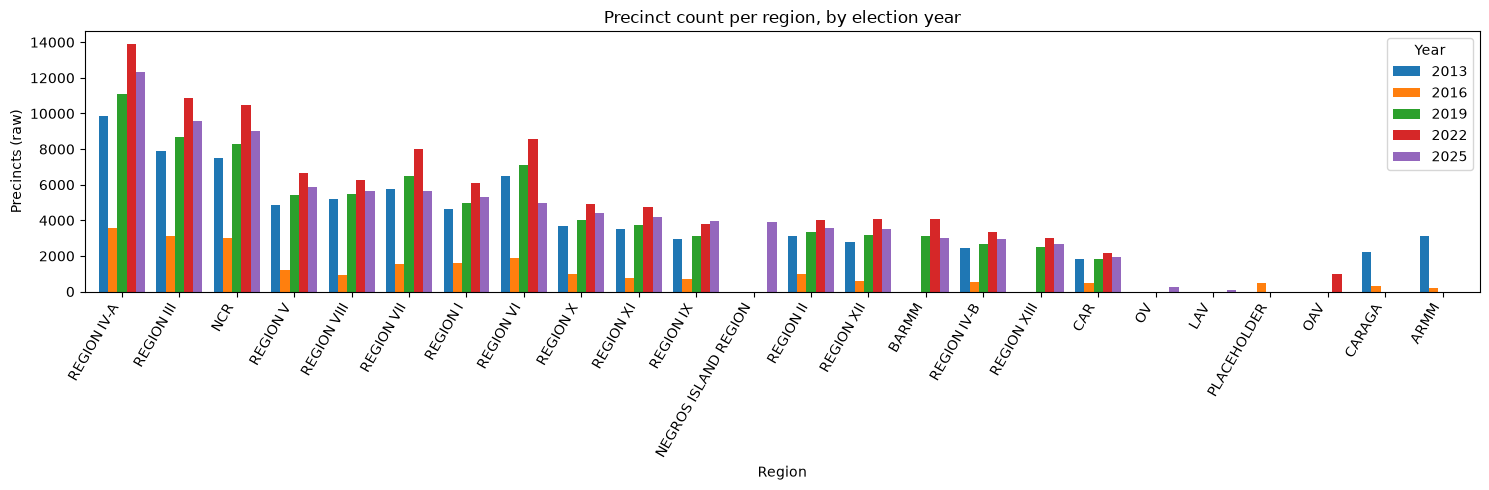

In [17]:
ax = region_counts.plot(kind='bar', figsize=(15, 5), width=0.8)
ax.set_ylabel('Precincts (raw)')
ax.set_xlabel('Region')
ax.set_title('Precinct count per region, by election year')
ax.legend(title='Year')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

## 3. Top-N candidates by total votes

Total raw votes summed across all precincts, per year. A quick check that the
expected front-runners top each race.

In [18]:
N = 12

def top_candidates(yr, n=N):
    d = D[yr]
    votes = d['df'][d['cand_cols']].apply(pd.to_numeric, errors='coerce').sum()
    votes.index = [clean_name(c) for c in votes.index]
    top = votes.sort_values(ascending=False).head(n)
    total = votes.sum()
    return pd.DataFrame({'votes': top.astype(int), 'share_%': (100 * top / total).round(2)})

for yr in YEARS:
    print(f'\n===== {yr}: top {N} senatorial candidates by total votes =====')
    print(top_candidates(yr).to_string())


===== 2013: top 12 senatorial candidates by total votes =====
                                    votes  share_%
POE, GRACE                       16344446     6.84
LEGARDA, LOREN (NPC)             14946578     6.26
ESCUDERO, CHIZ                   14140992     5.92
CAYETANO, ALAN PETER (NP)        14133550     5.92
BINAY, NANCY (UNA)               13313802     5.57
ANGARA, EDGARDO (LDP)            12856468     5.38
AQUINO, BENIGNO BAM (LP)         12379592     5.18
PIMENTEL, KOKO (PDP)             11849091     4.96
TRILLANES, ANTONIO IV (NP)       11392060     4.77
VILLAR, CYNTHIA HANEPBUHAY (NP)  11073129     4.64
EJERCITO ESTRADA, JV (UNA)       11013048     4.61
HONASAN, GRINGO (UNA)            10623499     4.45

===== 2016: top 12 senatorial candidates by total votes =====
                                  votes  share_%
VILLANUEVA, JOEL TESDAMAN (LP)  5185483     5.89
DRILON, FRANK (LP)              5041794     5.73
SOTTO, VICENTE (NPC)            4921233     5.59
GORDON, DICK (I

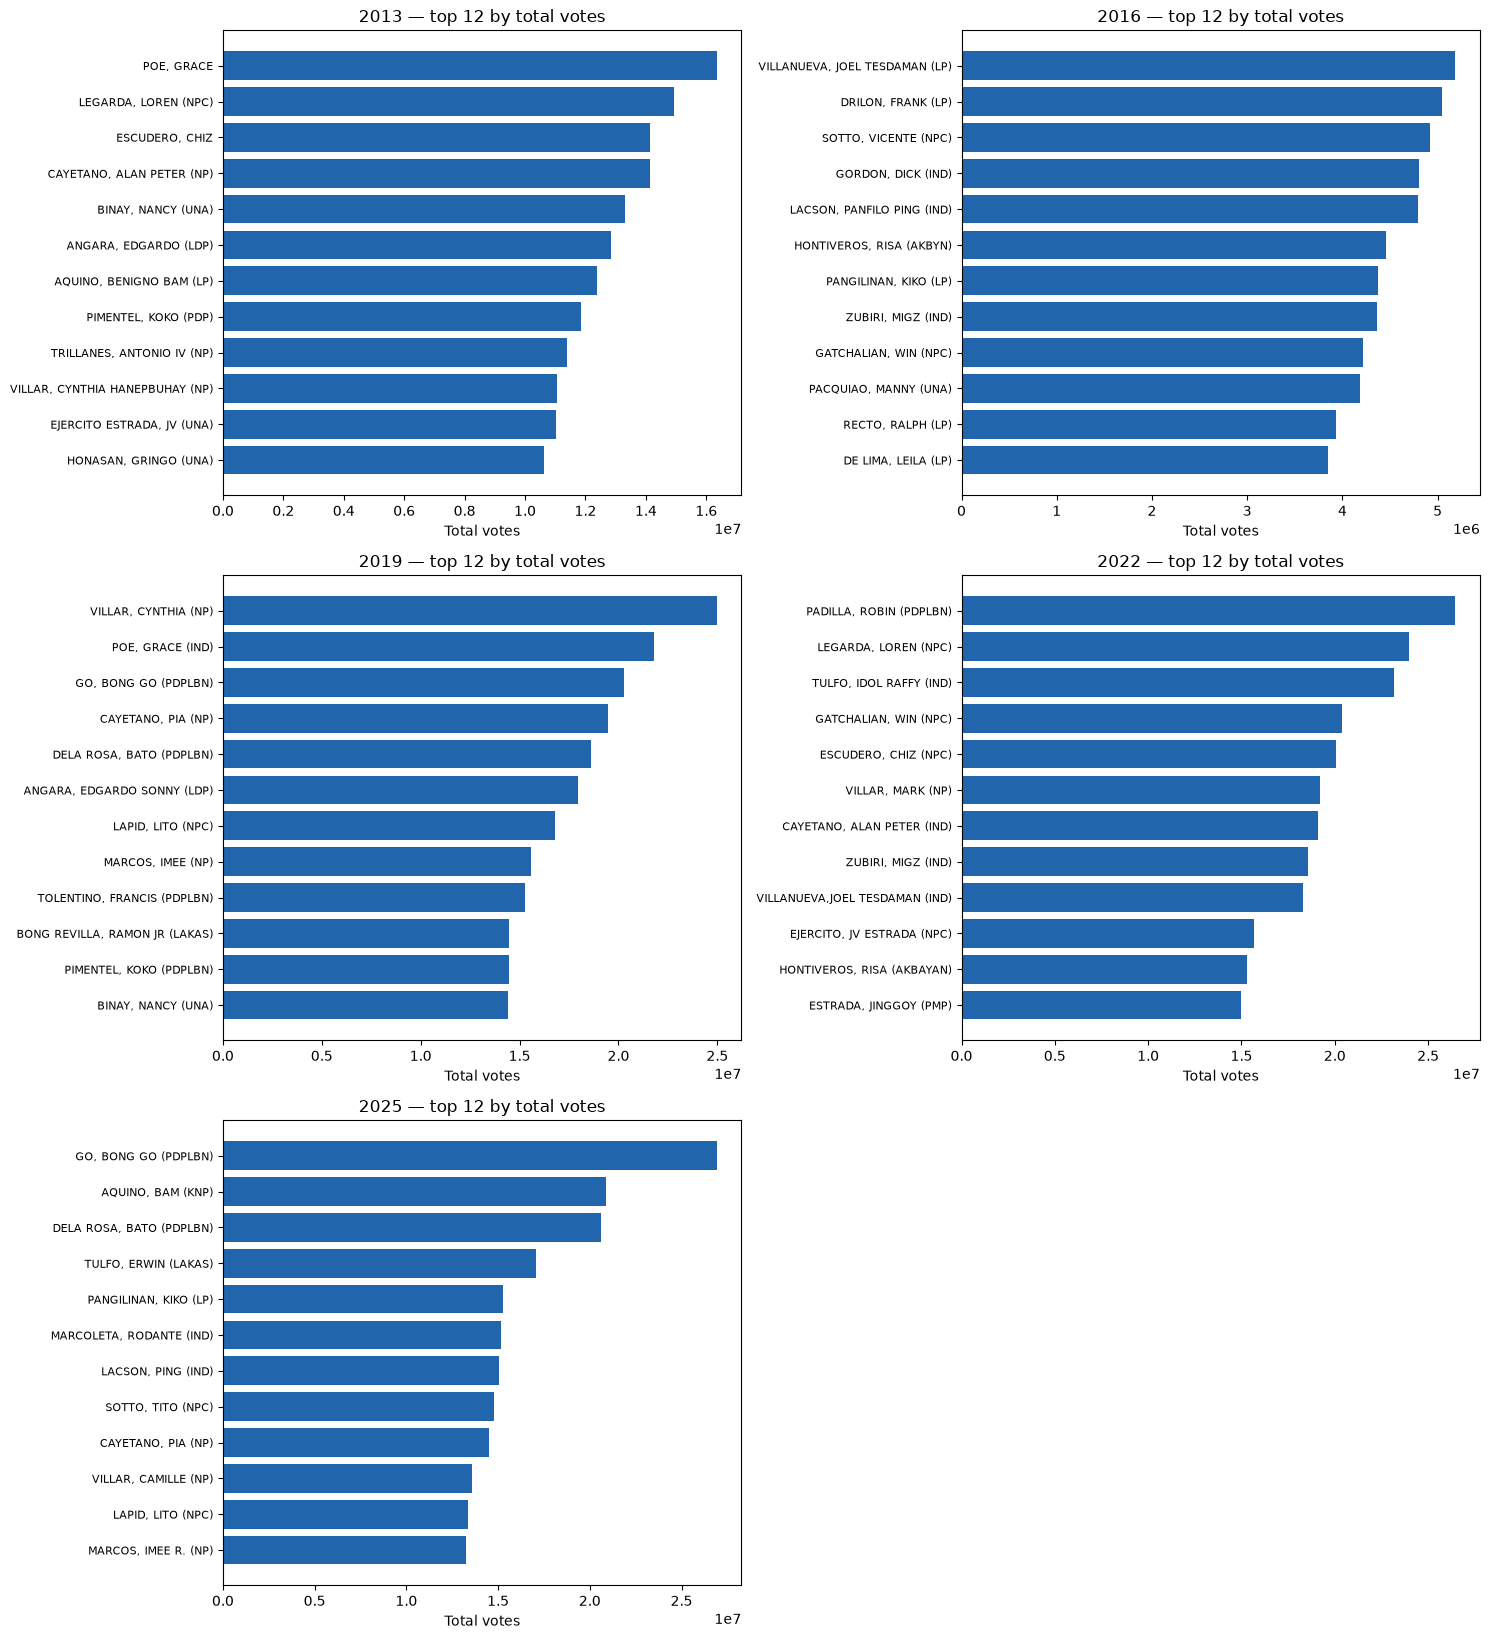

In [19]:
import math
ncols = 2
nrows = math.ceil(len(YEARS) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(15, 5.5 * nrows))
axs = np.atleast_1d(axs).reshape(-1)
for ax, yr in zip(axs, YEARS):
    t = top_candidates(yr).iloc[::-1]
    ax.barh(t.index, t['votes'], color='#2166ac')
    ax.set_title(f'{yr} — top {N} by total votes')
    ax.set_xlabel('Total votes')
    ax.tick_params(axis='y', labelsize=8)
for ax in axs[len(YEARS):]:          # hide any unused grid slots
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## 4. Registration & turnout sanity (where available)

2013 carries only registered voters; 2019/2022/2025 carry registered, actual,
and valid-ballot counts. National totals and derived rates below — sanity-check
that turnout sits in a plausible ~70–85% band and valid ≤ actual ≤ registered.

In [20]:
def reg_turnout(yr):
    df = D[yr]['df']
    def s(col):
        return pd.to_numeric(df[col], errors='coerce').sum() if col in df.columns else np.nan
    reg = s('information.numberOfRegisteredVoters')
    act = s('information.numberOfActuallyVoters')
    val = s('information.numberOfValidBallot')
    return {
        'registered': reg, 'actual_voters': act, 'valid_ballots': val,
        'turnout_% (act/reg)': round(100 * act / reg, 2) if reg and not np.isnan(act) else np.nan,
        'valid_%   (val/act)': round(100 * val / act, 2) if act and not np.isnan(val) else np.nan,
    }

pd.DataFrame({yr: reg_turnout(yr) for yr in YEARS})

,2013,2016,2019,2022,2025
registered,31571722.0,11354508.0,61438889.00,66202014.00,69298802.00
actual_voters,NaN,NaN,46665682.00,55201216.00,56972293.00
valid_ballots,NaN,NaN,46665682.00,55201216.00,62641530.00
turnout_% (act/reg),NaN,NaN,75.95,83.38,82.21
valid_% (val/act),NaN,NaN,100.00,100.00,109.95


## 5. Data-hygiene flags

Cheap red-flag checks on the raw candidate vote matrix and precinct ids. All the
NaN counts should be 0 (``load_complete`` drops any-NaN rows) and there should be
no negative votes.

In [27]:
def hygiene(yr):
    d = D[yr]
    df, cand = d['df'], d['cand_cols']
    V = df[cand].apply(pd.to_numeric, errors='coerce')
    pid = 'CLUSTERED_PRECINCT'
    return {
        'nan_vote_cells': int(V.isna().to_numpy().sum()),
        'negative_vote_cells': int((V < 0).to_numpy().sum()),
        'min_vote': int(np.nanmin(V.to_numpy())),
        'max_vote': int(np.nanmax(V.to_numpy())),
        'zero-vote precincts': int((V.sum(axis=1) == 0).sum()),
        'precinct_id_col': pid if pid in df.columns else '(none)',
        'duplicate_precinct_ids': int(df[pid].duplicated().sum()) if pid in df.columns else np.nan,
        'candidates_dropped_by_preproc': len(cand) - d['pre'].Y.shape[0],
    }

pd.DataFrame({yr: hygiene(yr) for yr in YEARS})

,2013,2016,2019,2022,2025
nan_vote_cells,0,0,0,0,0
negative_vote_cells,0,0,0,0,0
min_vote,0,0,0,0,0
max_vote,975,718,971,991,18630
zero-vote precincts,18151,0,2,359,77
precinct_id_col,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT
duplicate_precinct_ids,1,0,0,0,0
candidates_dropped_by_preproc,2,0,29,30,24


In [ ]:
def hygiene_filtered(yr):
    d = D[yr]
    cfg = d['cfg']
    excluded_regions = cfg['preprocessing'].get('excluded_regions', '').split(',')
    df, cand = d['df'].query(f'REGION not in {excluded_regions}'), d['cand_cols']
    V = df[cand].apply(pd.to_numeric, errors='coerce')
    pid = 'CLUSTERED_PRECINCT'
    return {
        'nan_vote_cells': int(V.isna().to_numpy().sum()),
        'negative_vote_cells': int((V < 0).to_numpy().sum()),
        'min_vote': int(np.nanmin(V.to_numpy())),
        'max_vote': int(np.nanmax(V.to_numpy())),
        'zero-vote precincts': int((V.sum(axis=1) == 0).sum()),
        'precinct_id_col': pid if pid in df.columns else '(none)',
        'duplicate_precinct_ids': int(df[pid].duplicated().sum()) if pid in df.columns else np.nan,
        'candidates_dropped_by_preproc': len(cand) - d['pre'].Y.shape[0],
    }

pd.DataFrame({yr: hygiene(yr) for yr in YEARS})

,2013,2016,2019,2022,2025
nan_vote_cells,0,0,0,0,0
negative_vote_cells,0,0,0,0,0
min_vote,0,0,0,0,0
max_vote,975,718,971,991,993
zero-vote precincts,18151,0,2,359,43
precinct_id_col,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT,CLUSTERED_PRECINCT
duplicate_precinct_ids,1,0,0,0,0
candidates_dropped_by_preproc,2,0,29,30,24


## 6. Counts at a glance

Precincts and candidate counts side by side — raw vs. kept.

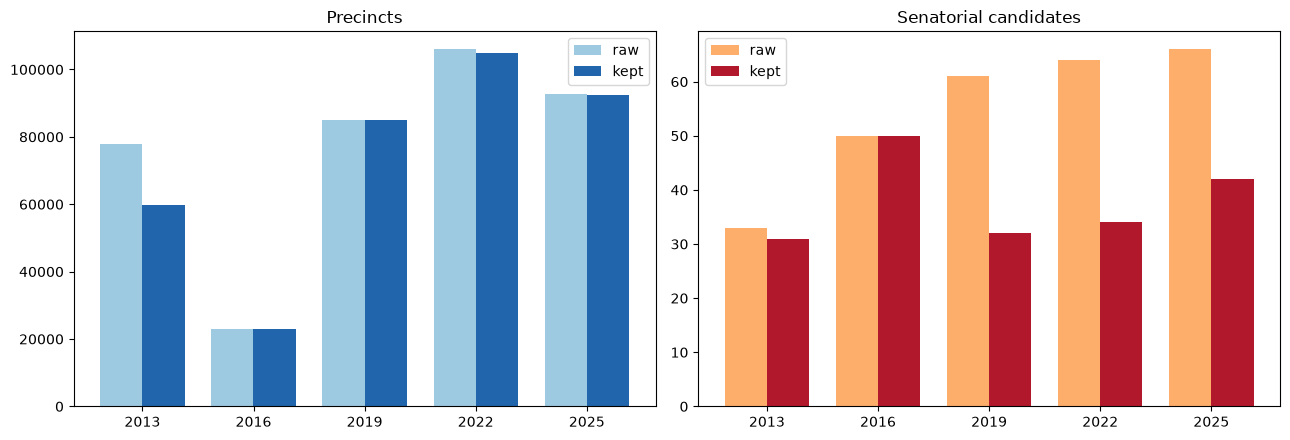

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(YEARS))
w = 0.38
raw_p = [D[y]['df'].shape[0] for y in YEARS]
kept_p = [D[y]['pre'].Y.shape[1] for y in YEARS]
raw_c = [len(D[y]['cand_cols']) for y in YEARS]
kept_c = [D[y]['pre'].Y.shape[0] for y in YEARS]

axs[0].bar(x - w/2, raw_p, w, label='raw', color='#9ecae1')
axs[0].bar(x + w/2, kept_p, w, label='kept', color='#2166ac')
axs[0].set_title('Precincts')
axs[1].bar(x - w/2, raw_c, w, label='raw', color='#fdae6b')
axs[1].bar(x + w/2, kept_c, w, label='kept', color='#b2182b')
axs[1].set_title('Senatorial candidates')
for ax in axs:
    ax.set_xticks(x); ax.set_xticklabels(YEARS); ax.legend()
fig.tight_layout()
plt.show()

## 7. Focus — the 18k dropped 2013 precincts

Section 1 shows 2013 dropping ~18k precincts, far more than any other year. Every
one is an **empty row** (zero votes across all 33 candidates), not a real precinct
lost to the filters — so nothing meaningful is discarded. This confirms that and
shows which regions the empty rows come from, both as a raw count and as a share
of each region's rows. They coincide with the zero-registered-voter placeholder
rows (empty vote row ⇒ empty registration), i.e. master-list precinct slots with
no transmitted returns.

dropped precincts:             18,151
empty rows (0 votes / all 33): 18,151   -> dropped are exactly the empty rows: True
empty AND zero registered voters: 18,149 / 18,151


,raw_precincts,empty_precincts,empty_%_of_region
REGION,,,
ARMM,3124,2036,65.2
REGION IX,2968,1122,37.8
CAR,1828,689,37.7
REGION II,3114,929,29.8
REGION X,3701,1099,29.7
REGION IV-B,2421,662,27.3
REGION XII,2807,747,26.6
REGION VIII,5173,1366,26.4
REGION I,4623,1090,23.6


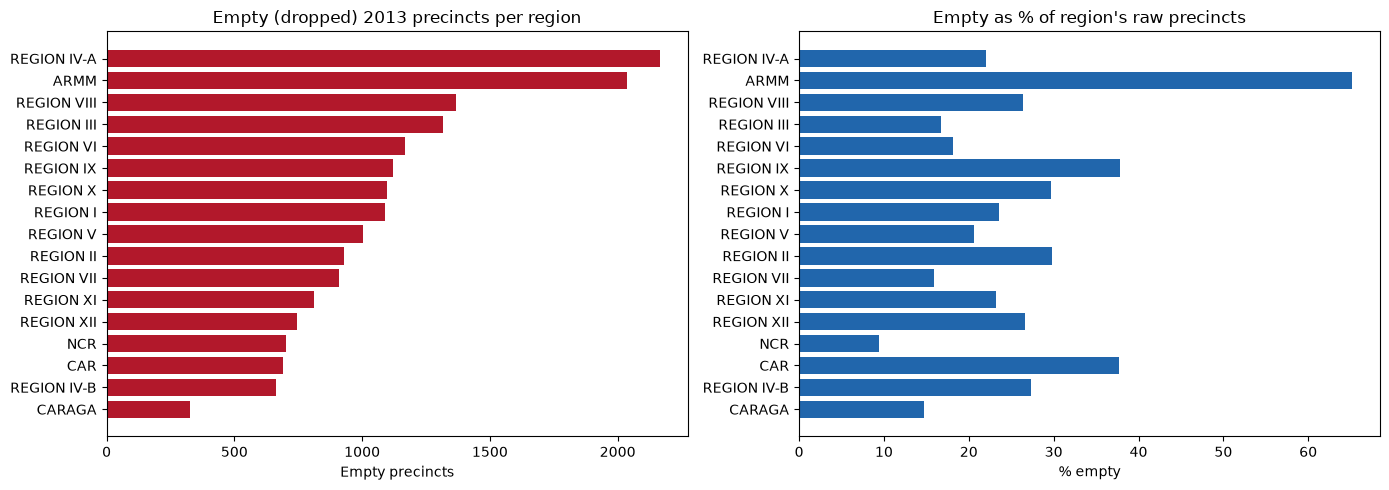

In [10]:
d13 = D['2013']
df13 = d13['df']
V13 = df13[d13['cand_cols']].apply(pd.to_numeric, errors='coerce')

empty = V13.sum(axis=1) == 0                     # zero votes across all 33 candidates
n_dropped = len(df13) - d13['pre'].Y.shape[1]
reg0 = pd.to_numeric(df13['information.numberOfRegisteredVoters'], errors='coerce') == 0

print(f"dropped precincts:             {n_dropped:,}")
print(f"empty rows (0 votes / all 33): {int(empty.sum()):,}"
      f"   -> dropped are exactly the empty rows: {n_dropped == int(empty.sum())}")
print(f"empty AND zero registered voters: {int((empty & reg0).sum()):,} / {int(empty.sum()):,}")

# Which regions the empty rows come from: count, and share of each region's rows.
brk = pd.DataFrame({
    'raw_precincts':   df13['REGION'].value_counts(),
    'empty_precincts': df13.loc[empty, 'REGION'].value_counts(),
}).fillna(0).astype(int)
brk['empty_%_of_region'] = (100 * brk['empty_precincts'] / brk['raw_precincts']).round(1)
brk = brk.sort_values('empty_%_of_region', ascending=False)
display(brk)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
b = brk.sort_values('empty_precincts')
axs[0].barh(b.index, b['empty_precincts'], color='#b2182b')
axs[0].set_title('Empty (dropped) 2013 precincts per region')
axs[0].set_xlabel('Empty precincts')
axs[1].barh(b.index, b['empty_%_of_region'], color='#2166ac')
axs[1].set_title("Empty as % of region's raw precincts")
axs[1].set_xlabel('% empty')
fig.tight_layout()
plt.show()